In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [2]:
df = pd.read_csv(r"weight-height.csv")
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [3]:
df = df[['Weight','Height']]
df.head()

,Weight,Height
0,241.893563,73.847017
1,162.310473,68.781904
2,212.740856,74.110105
3,220.042470,71.730978
4,206.349801,69.881796


In [4]:
df.shape

(10000, 2)

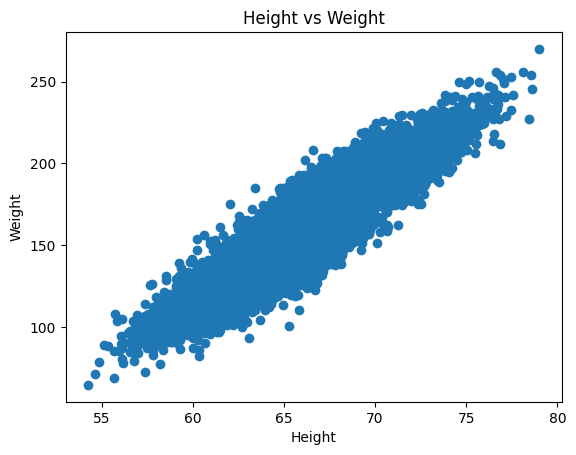

In [5]:
plt.scatter(df['Height'],df['Weight'])
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Height vs Weight')
plt.show()

In [6]:
df.corr()

,Weight,Height
Weight,1.000000,0.924756
Height,0.924756,1.000000


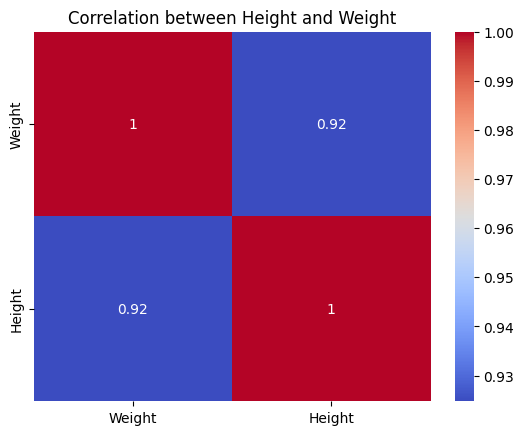

In [7]:
sns.heatmap(df.corr(),annot=True, cmap='coolwarm')
plt.title('Correlation between Height and Weight')
plt.show()

In [8]:
X = df[['Weight']] #2d why?  , capital , input
y = df['Height']   #1d , small letter , output
#why 1d and 2d , because sklearn expects the input features to be in a 2D array format
# # (even if there's only one feature), while the target variable can be in a 1D array format.


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [10]:
#Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

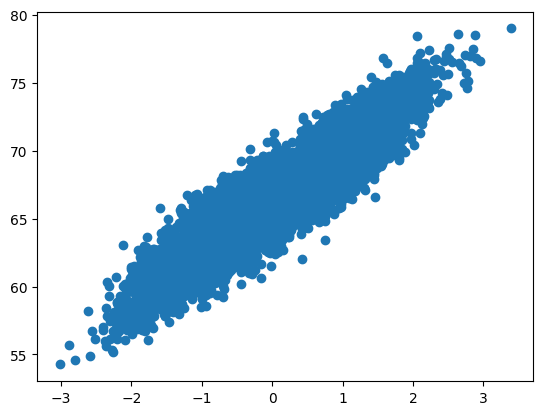

In [11]:
plt.scatter(X_train,y_train)

In [12]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()


In [13]:
regressor

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
type(X_train)

numpy.ndarray

In [15]:
X_train.shape

(8000, 1)

In [16]:
#X_train = np.array(X_train).reshape(-1,1).shape
#X_test = np.array(X_test).reshape(-1,1).shape

In [17]:
regressor.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[3.55]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,66.36
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[89.44]


In [18]:
print('Coefficient:', regressor.coef_)
print('Intercept:', regressor.intercept_)

Coefficient: [3.55479288]
Intercept: 66.3596814074891


Text(0, 0.5, 'Height')

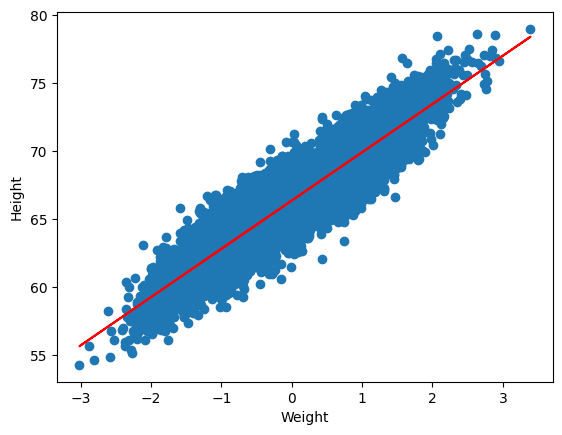

In [19]:
plt.scatter(X_train,y_train)
plt.plot(X_train, regressor.predict(X_train), color='red')
plt.xlabel('Weight')
plt.ylabel('Height')


In [20]:
y_pred = regressor.predict(X_test)
y_pred

array([67.66759668, 70.11347651, 67.34604311, ..., 62.34937415,
       69.27157847, 59.829821  ], shape=(2000,))

In [21]:
y_test

6252    68.687232
4684    68.829334
1731    66.398128
4742    71.929340
4521    67.042903
          ...    
6412    65.748601
8285    60.731857
7853    62.188933
1095    67.068304
6929    58.632720
Name: Height, Length: 2000, dtype: float64

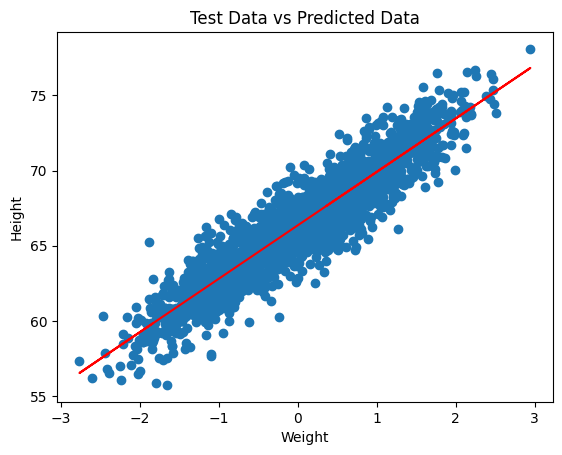

In [22]:
plt.scatter(X_test,y_test)
plt.plot(X_test, y_pred, color='red')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Test Data vs Predicted Data')
plt.show()

In [23]:
from sklearn.metrics import mean_squared_error, r2_score , mean_absolute_error
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('Mean Squared Error:', mse)
print('Mean Absolute Error:', mae)
print('Root Mean Squared Error:', rmse)
print('R-squared:', r2)




Mean Squared Error: 2.112361948474147
Mean Absolute Error: 1.1588656330992098
Root Mean Squared Error: 1.4533966934303062
R-squared: 0.8578120230894554


In [24]:
1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)

0.8577408579358465

In [25]:
regressor.predict(scaler.transform([[150]]))

C:\Users\Acer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([65.10305385])

In [26]:
residuals = y_test - y_pred
residuals

6252    1.019636
4684   -1.284143
1731   -0.947915
4742   -0.390533
4521   -1.690374
          ...   
6412    1.525611
8285   -1.039337
7853   -0.160441
1095   -2.203274
6929   -1.197101
Name: Height, Length: 2000, dtype: float64

<Axes: xlabel='Height', ylabel='Count'>

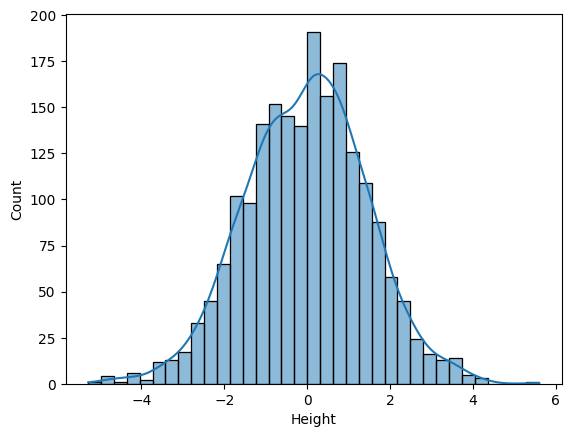

In [27]:
sns.histplot(residuals, kde=True)

In [28]:
import joblib
joblib.dump(regressor, 'linear_regression_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [29]:
regressor_loaded = joblib.load('linear_regression_model.pkl')
scalar_loaded = joblib.load('scaler.pkl')

In [30]:
regressor.predict(scaler.transform([[150]]))


C:\Users\Acer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([65.10305385])

In [31]:
print("150 pounds is approximately", regressor.predict(scaler.transform([[150]]))[0], "inches tall.")

150 pounds is approximately 65.10305385374997 inches tall.


C:\Users\Acer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [32]:
77 * 2.2

169.4

In [33]:
print("66 kg is approximately", regressor.predict(scaler.transform([[169.4]]))[0], "inches tall.")

66 kg is approximately 67.25535244259099 inches tall.


C:\Users\Acer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [34]:
67.25535244259099 * 2.54

170.8285952041811

In [35]:
print(f"Your height is approximately {67.25535244259099 * 2.54  / 30.48} feet tall  which is about 5'5")

Your height is approximately 5.6046127035492495 feet tall  which is about 5'5
